In [1]:
from fontTools.misc.iterTools import batched

from engine.Value import Value
from engine.nn import Neuron,Layer,MLP

import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
np.random.seed(1337)
random.seed(1337)

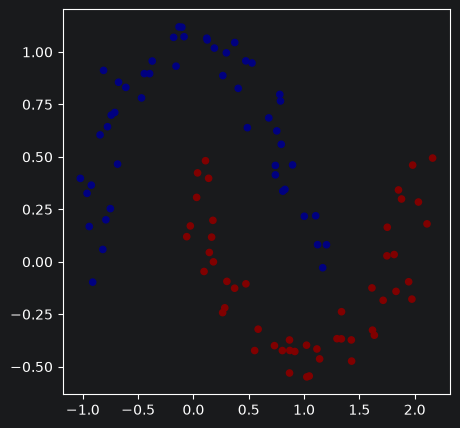

In [3]:
# make up a dataset

from sklearn.datasets import make_moons, make_blobs
X, y = make_moons(n_samples=100, noise=0.1)

y = y*2 - 1 # make y be -1 or 1
# visualize in 2D
plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=y, s=20, cmap='jet')

In [4]:
# initialize a model

print(Layer)

model = MLP(2, [16, 16, 1]) # 2-layer neural network
print(model)
print("number of parameters", len(model.parameters()))

<class 'engine.nn.Layer'>
MLP of [<engine.nn.Layer object at 0x7f504f578e50>, <engine.nn.Layer object at 0x7f504f3df190>, <engine.nn.Layer object at 0x7f504d2c9210>]
number of parameters 337


In [5]:
def loss(batch_size = None):
    if batch_size is None:
        xb, yb = X, y
    else:
        ri = np.random.permutation(X.shape[0])[:batch_size]
        xb, yb = X[ri], y[ri]
    xb_val = [list(map(Value, xi)) for xi in xb] #两层list 是因为xb本身也是一层list

    scores = list(map(model, xb_val))

    loss = [(1 - yi * s).relu() for yi, s in zip(yb, scores)]
    data_loss = sum(loss) * (1.0 / len(loss))

    ##正则化
    alpha = 1e-4
    reg_loss = alpha * sum( [(p * p) for p in model.parameters()])

    total_loss = data_loss + reg_loss
    # also get accuracy
    accuracy = [(yi > 0) == (scorei.data > 0) for yi, scorei in zip(yb, scores)]
    return total_loss, sum(accuracy) / len(accuracy)


In [7]:
# optimization
for k in range(100):

    # forward
    total_loss, acc = loss()

    # backward
    model.zero_grad()
    total_loss.backward()

    # update (sgd)
    learning_rate = 1.0 - 0.9*k/100
    for p in model.parameters():
        p.data -= learning_rate * p.grad

    if k % 1 == 0:
        print(f"step {k} loss {total_loss.data}, accuracy {acc*100}%")

step 0 loss 0.0617474962582906, accuracy 97.0%
step 1 loss 0.1489931661111691, accuracy 95.0%
step 2 loss 0.5764410603511914, accuracy 85.0%
step 3 loss 0.16007215682311912, accuracy 93.0%
step 4 loss 0.1065020820621319, accuracy 96.0%
step 5 loss 0.11362807111409934, accuracy 96.0%
step 6 loss 0.08573269401487725, accuracy 98.0%
step 7 loss 0.16284917464389426, accuracy 93.0%
step 8 loss 0.05805893939705949, accuracy 99.0%
step 9 loss 0.06906430405986029, accuracy 97.0%
step 10 loss 0.06053443607914987, accuracy 98.0%
step 11 loss 0.0868784077123194, accuracy 97.0%
step 12 loss 0.03128892230217228, accuracy 100.0%
step 13 loss 0.028367406536362376, accuracy 100.0%
step 14 loss 0.028082812096968633, accuracy 100.0%
step 15 loss 0.033246613248519984, accuracy 99.0%
step 16 loss 0.055424654875132845, accuracy 100.0%
step 17 loss 0.13534537101930152, accuracy 95.0%
step 18 loss 0.05618192417747496, accuracy 97.0%
step 19 loss 0.023079701752759203, accuracy 100.0%
step 20 loss 0.0263405861

(-1.548639298268643, 1.951360701731357)

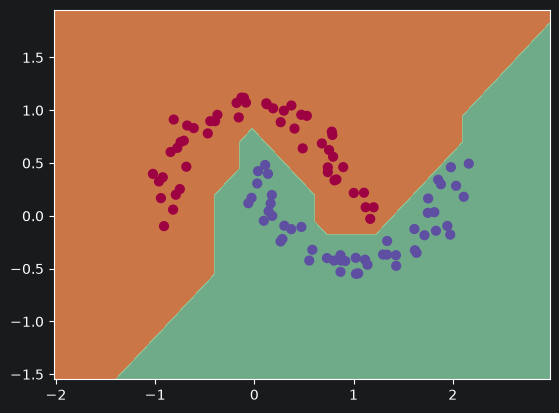

In [8]:
# visualize decision boundary

h = 0.25
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Xmesh = np.c_[xx.ravel(), yy.ravel()]
inputs = [list(map(Value, xrow)) for xrow in Xmesh]
scores = list(map(model, inputs))
Z = np.array([s.data > 0 for s in scores])
Z = Z.reshape(xx.shape)

fig = plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())

## 学习 mirco_grad 的问题

- pytorch使用的是数值梯度还是解析梯度
- 数值梯度只是用于梯度的正确性验证，pytorch中的函数还是解析梯度

- 数值梯度的优劣或者为什么不适用数值梯度
- 数值梯度在大参数模型下，计算会陡增，并且维度过高（维度指的是待优化量的维度），误差就大，相比于反向传播，计算小且精确
- 举例 loss 对x求导，就需要x+h 前向传播一次

- map实现 **一个函数逐个作用到可迭代对象的每个元素上**，但返回的是**惰性迭代器** 不是 **list**
- 出现一次损失不下降的原因是：loss的梯度要赋值为1.00，否则为0，后面的梯度都为0，无法更新参数